In [10]:
from ultralytics import YOLO
import torch
from IPython.display import Image, display
import glob

In [11]:
# Проверяем наличие CUDA
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Используется GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA не найдена, используется CPU")

Используется GPU: NVIDIA GeForce RTX 3060


In [12]:
model = YOLO('yolov8n.pt')

results = model.train(
    data='dataset.yaml',
    epochs=10,
    imgsz=640,
    batch=16,
    device=device,
)

engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False,

In [13]:
metrics = model.val(data='dataset.yaml', device=device)

print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")
print(f"F1 Score: {metrics.box.f1.mean():.4f}")

Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2496.61054.9 MB/s, size: 2334.1 KB)
val: Scanning C:\Users\Tony\Documents\II_labs\dataset\yolo_dataset\labels\val.cache... 310 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310 130.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.0it/s 10.1s.2s
                   all        310       1924       0.97      0.955      0.986      0.774
Speed: 0.7ms preprocess, 15.5ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to C:\Users\Tony\Documents\II_labs\runs\detect\val-2
mAP50: 0.9855
mAP50-95: 0.7744
Precision: 0.9699
Recall: 0.9548
F1 Score: 0.9623


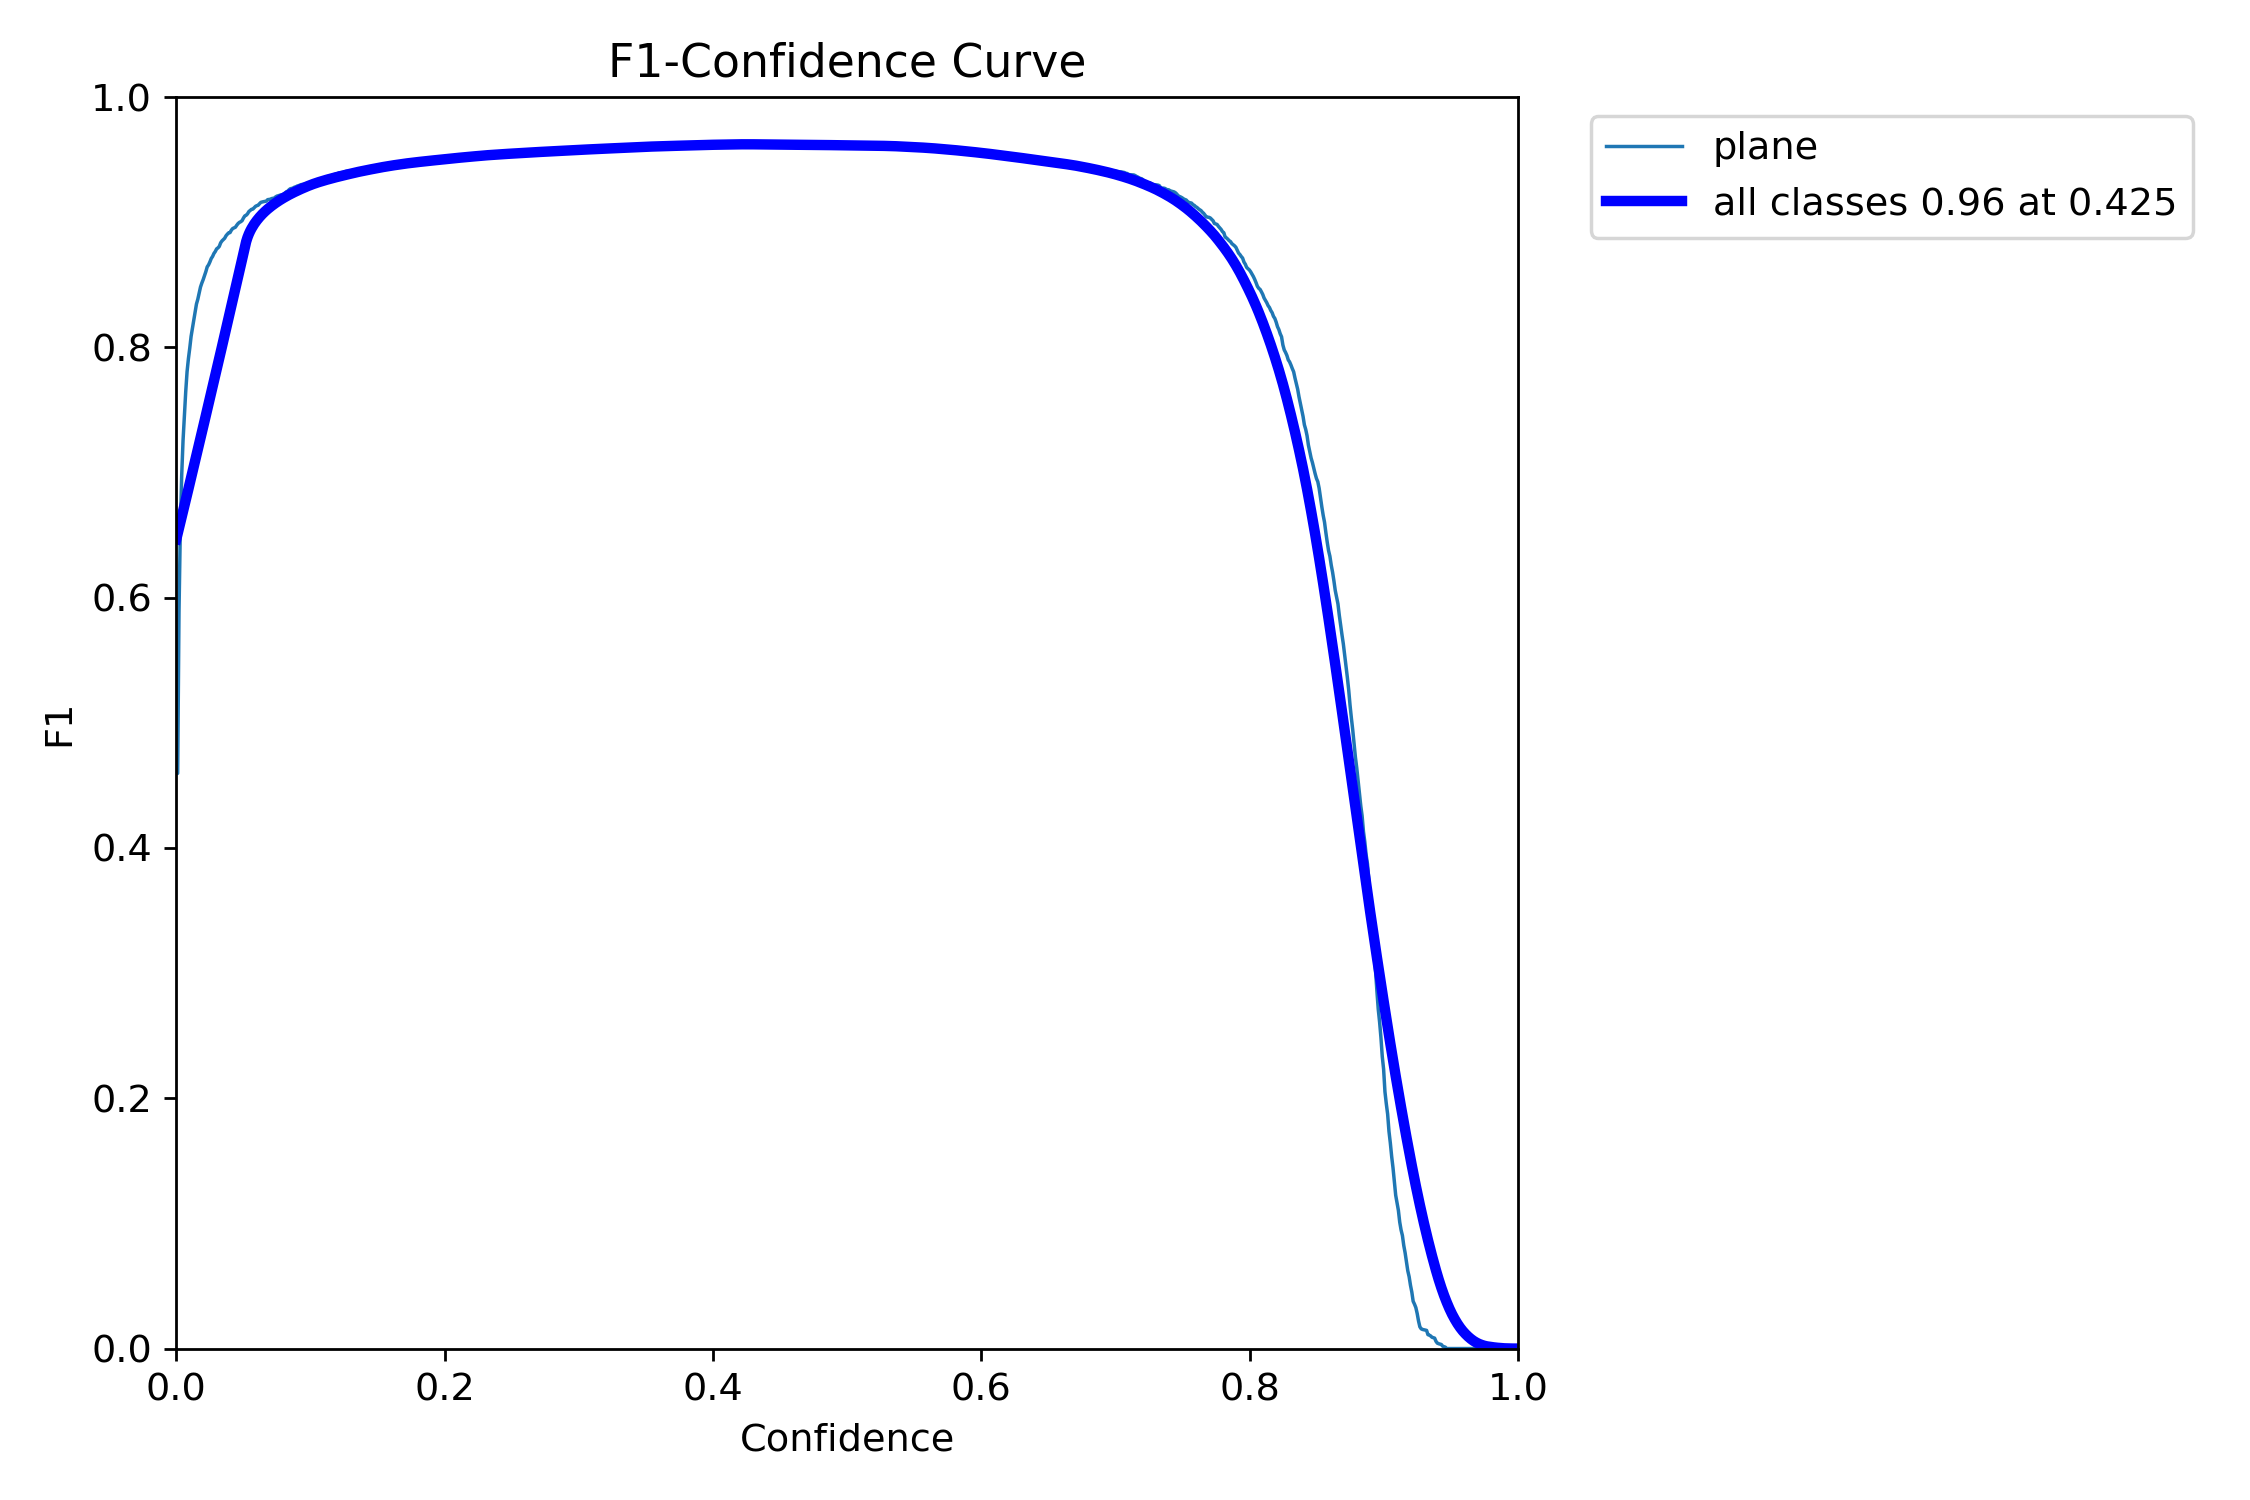

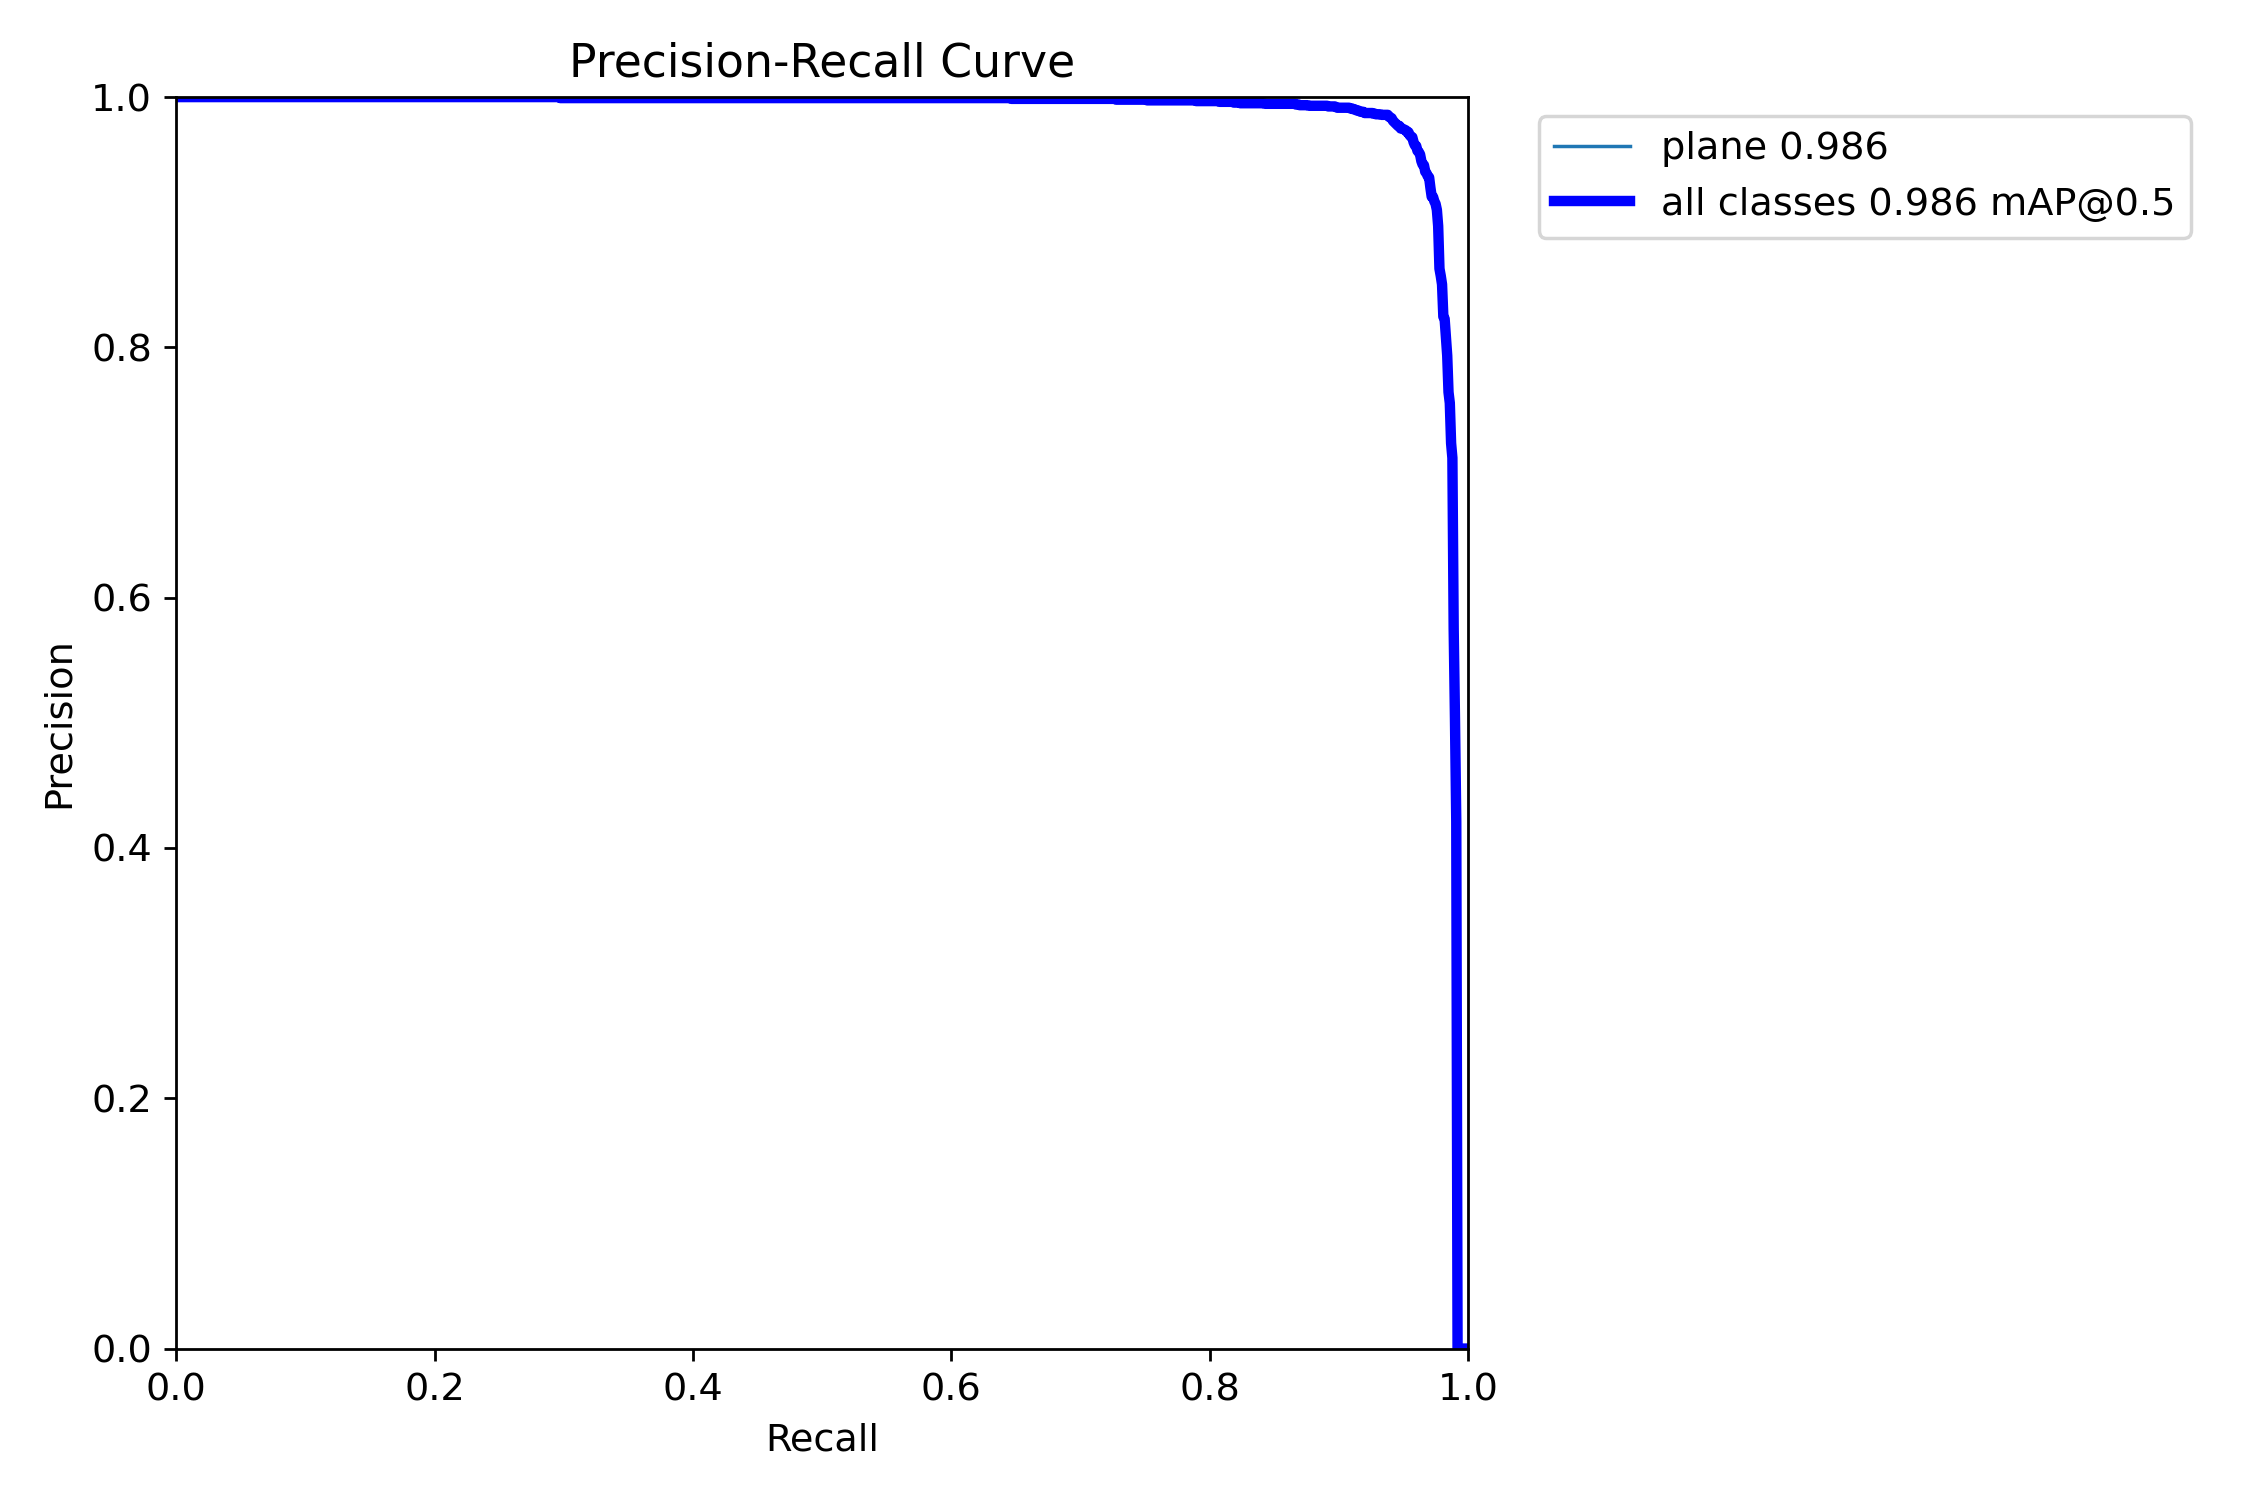

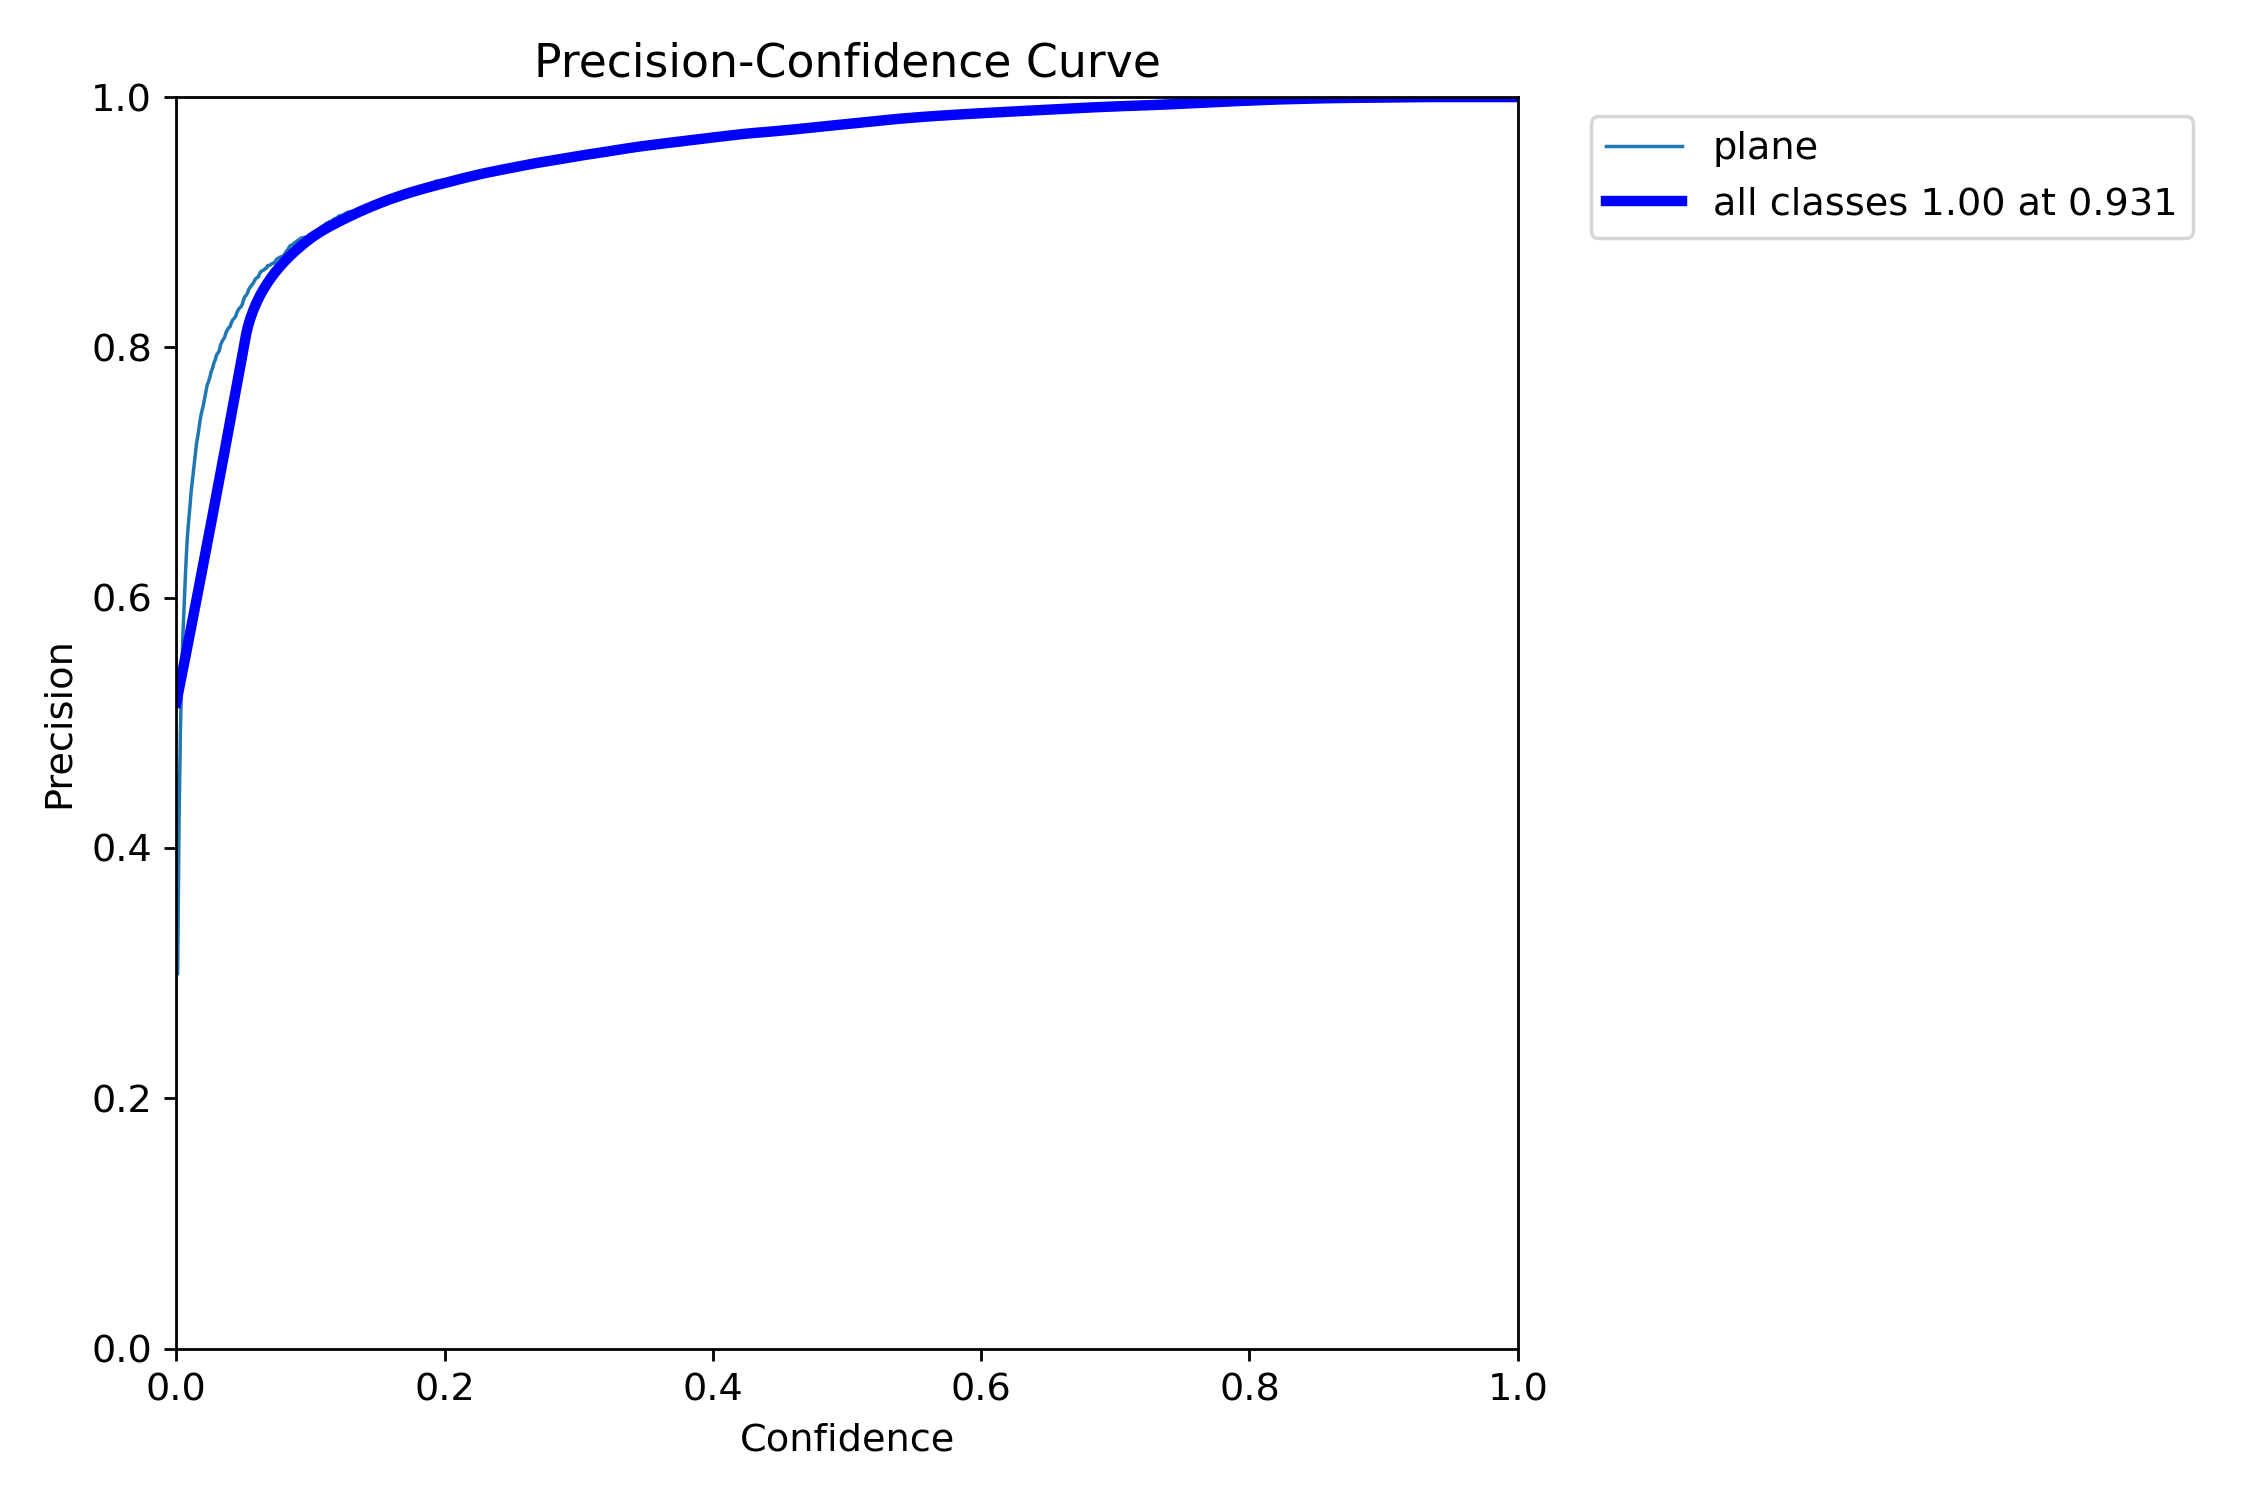

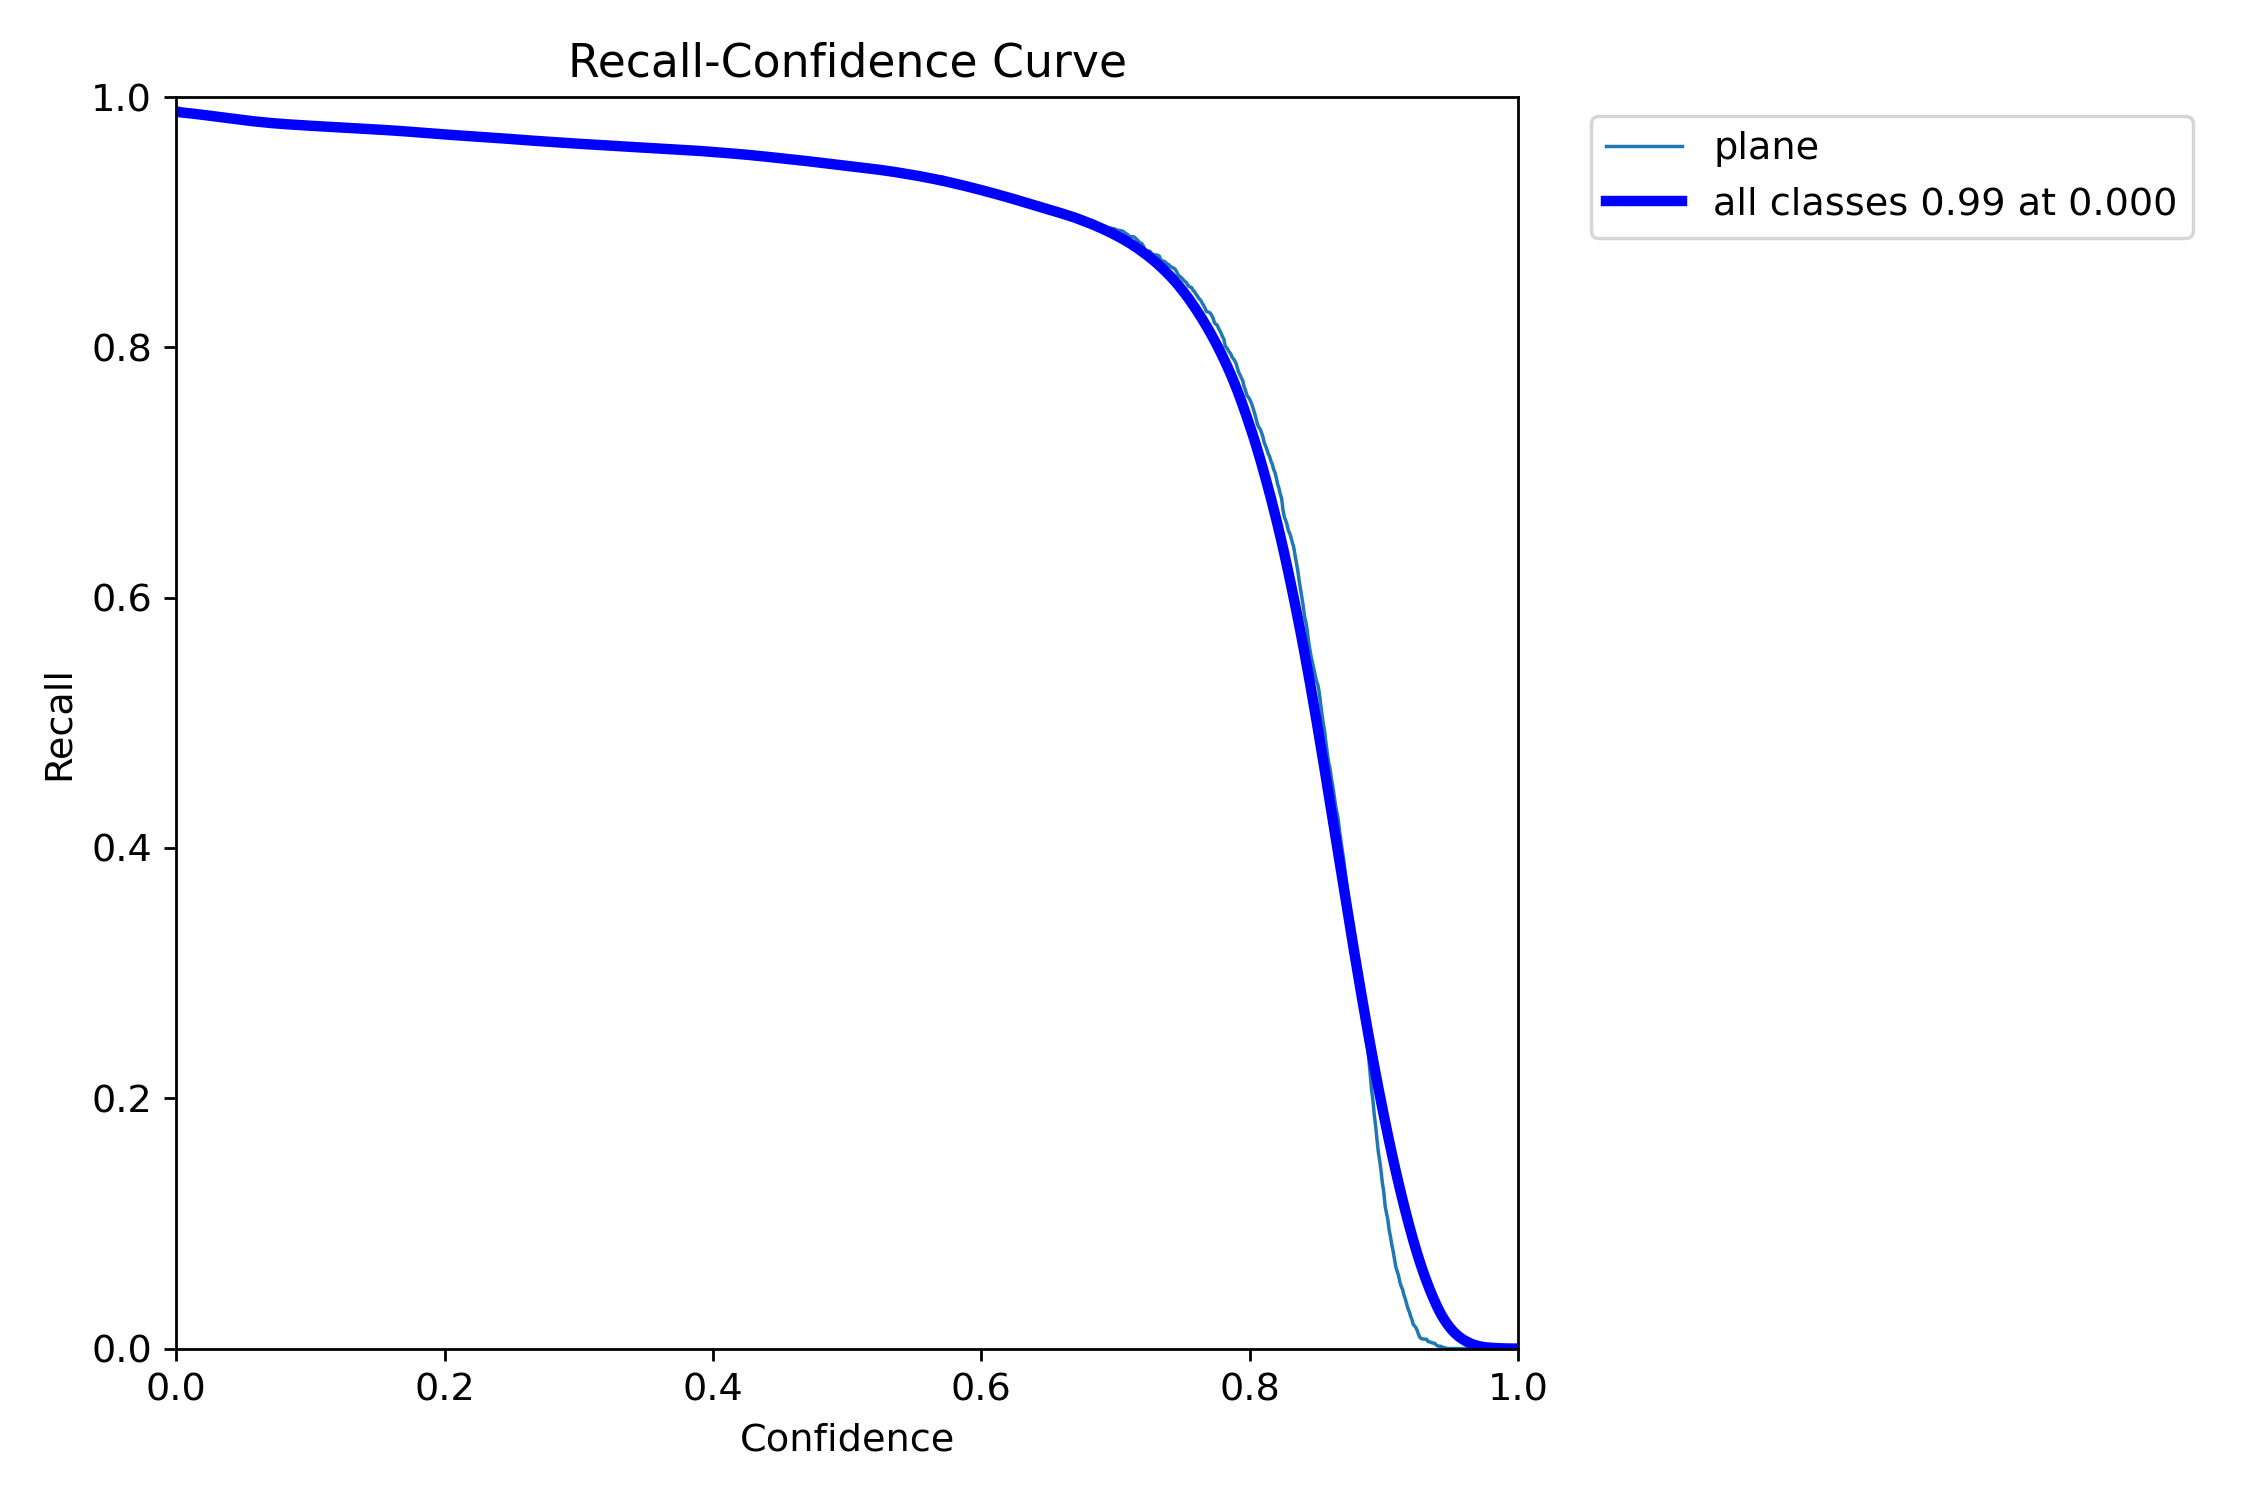

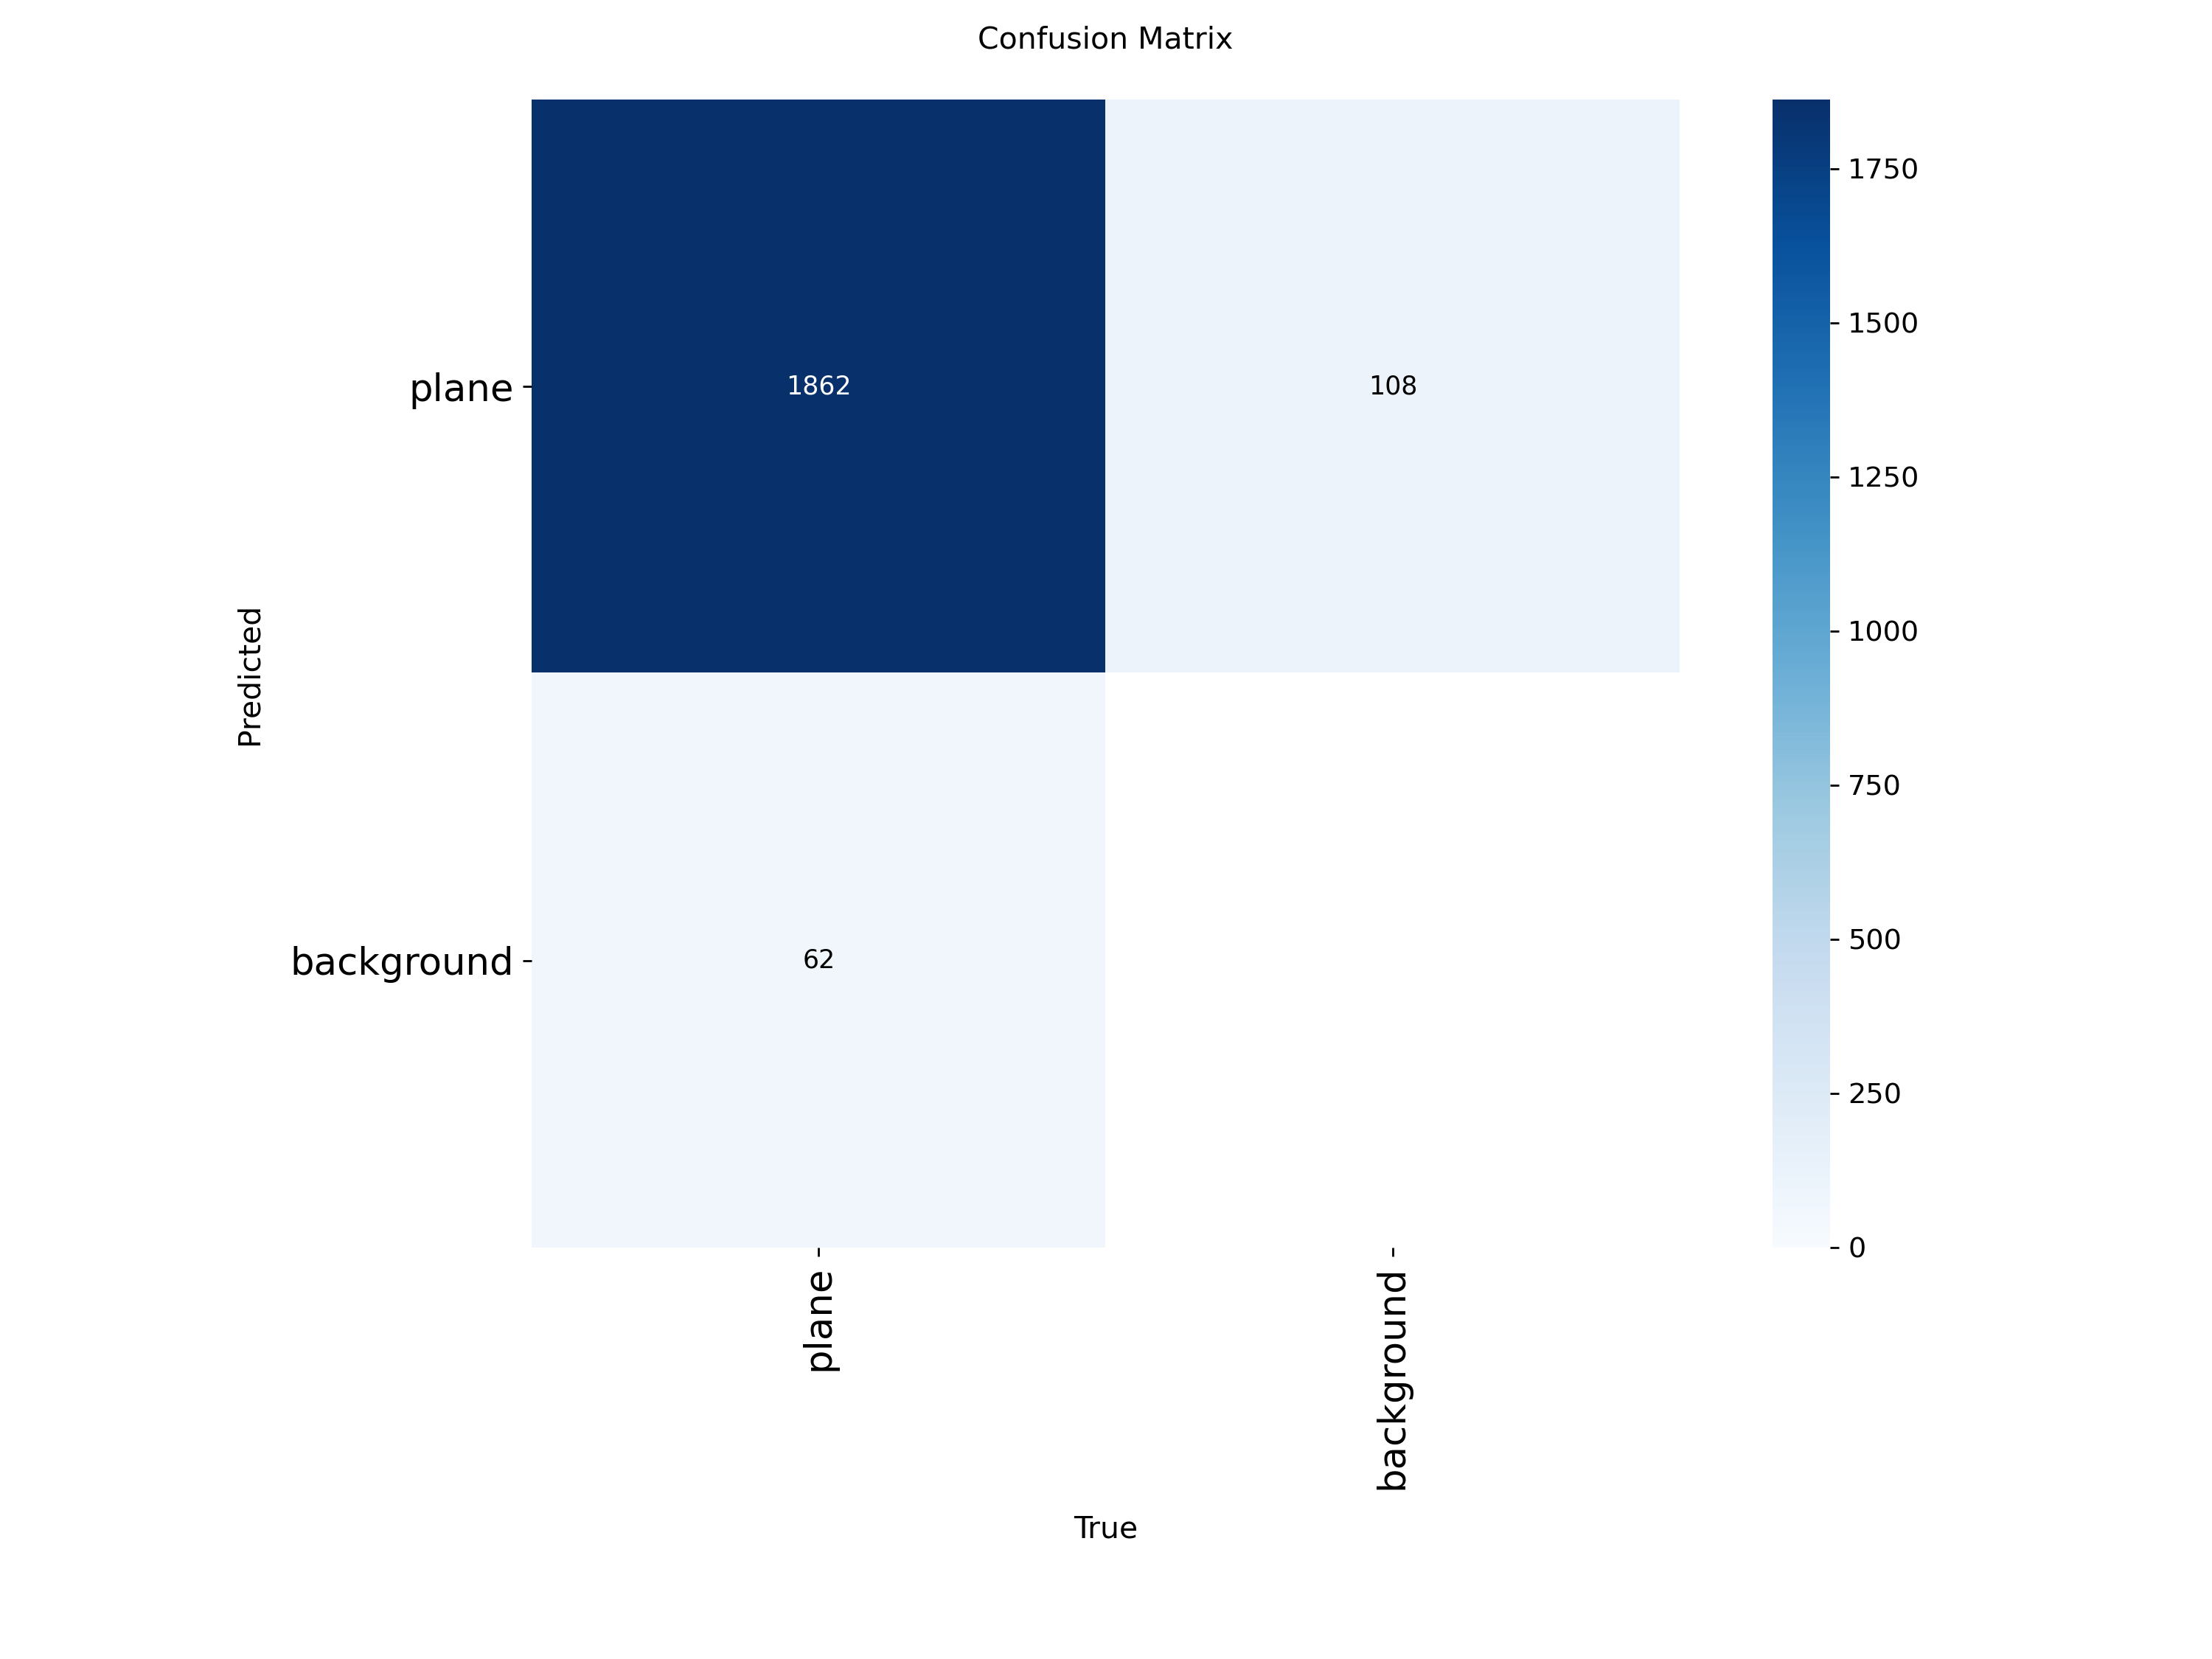

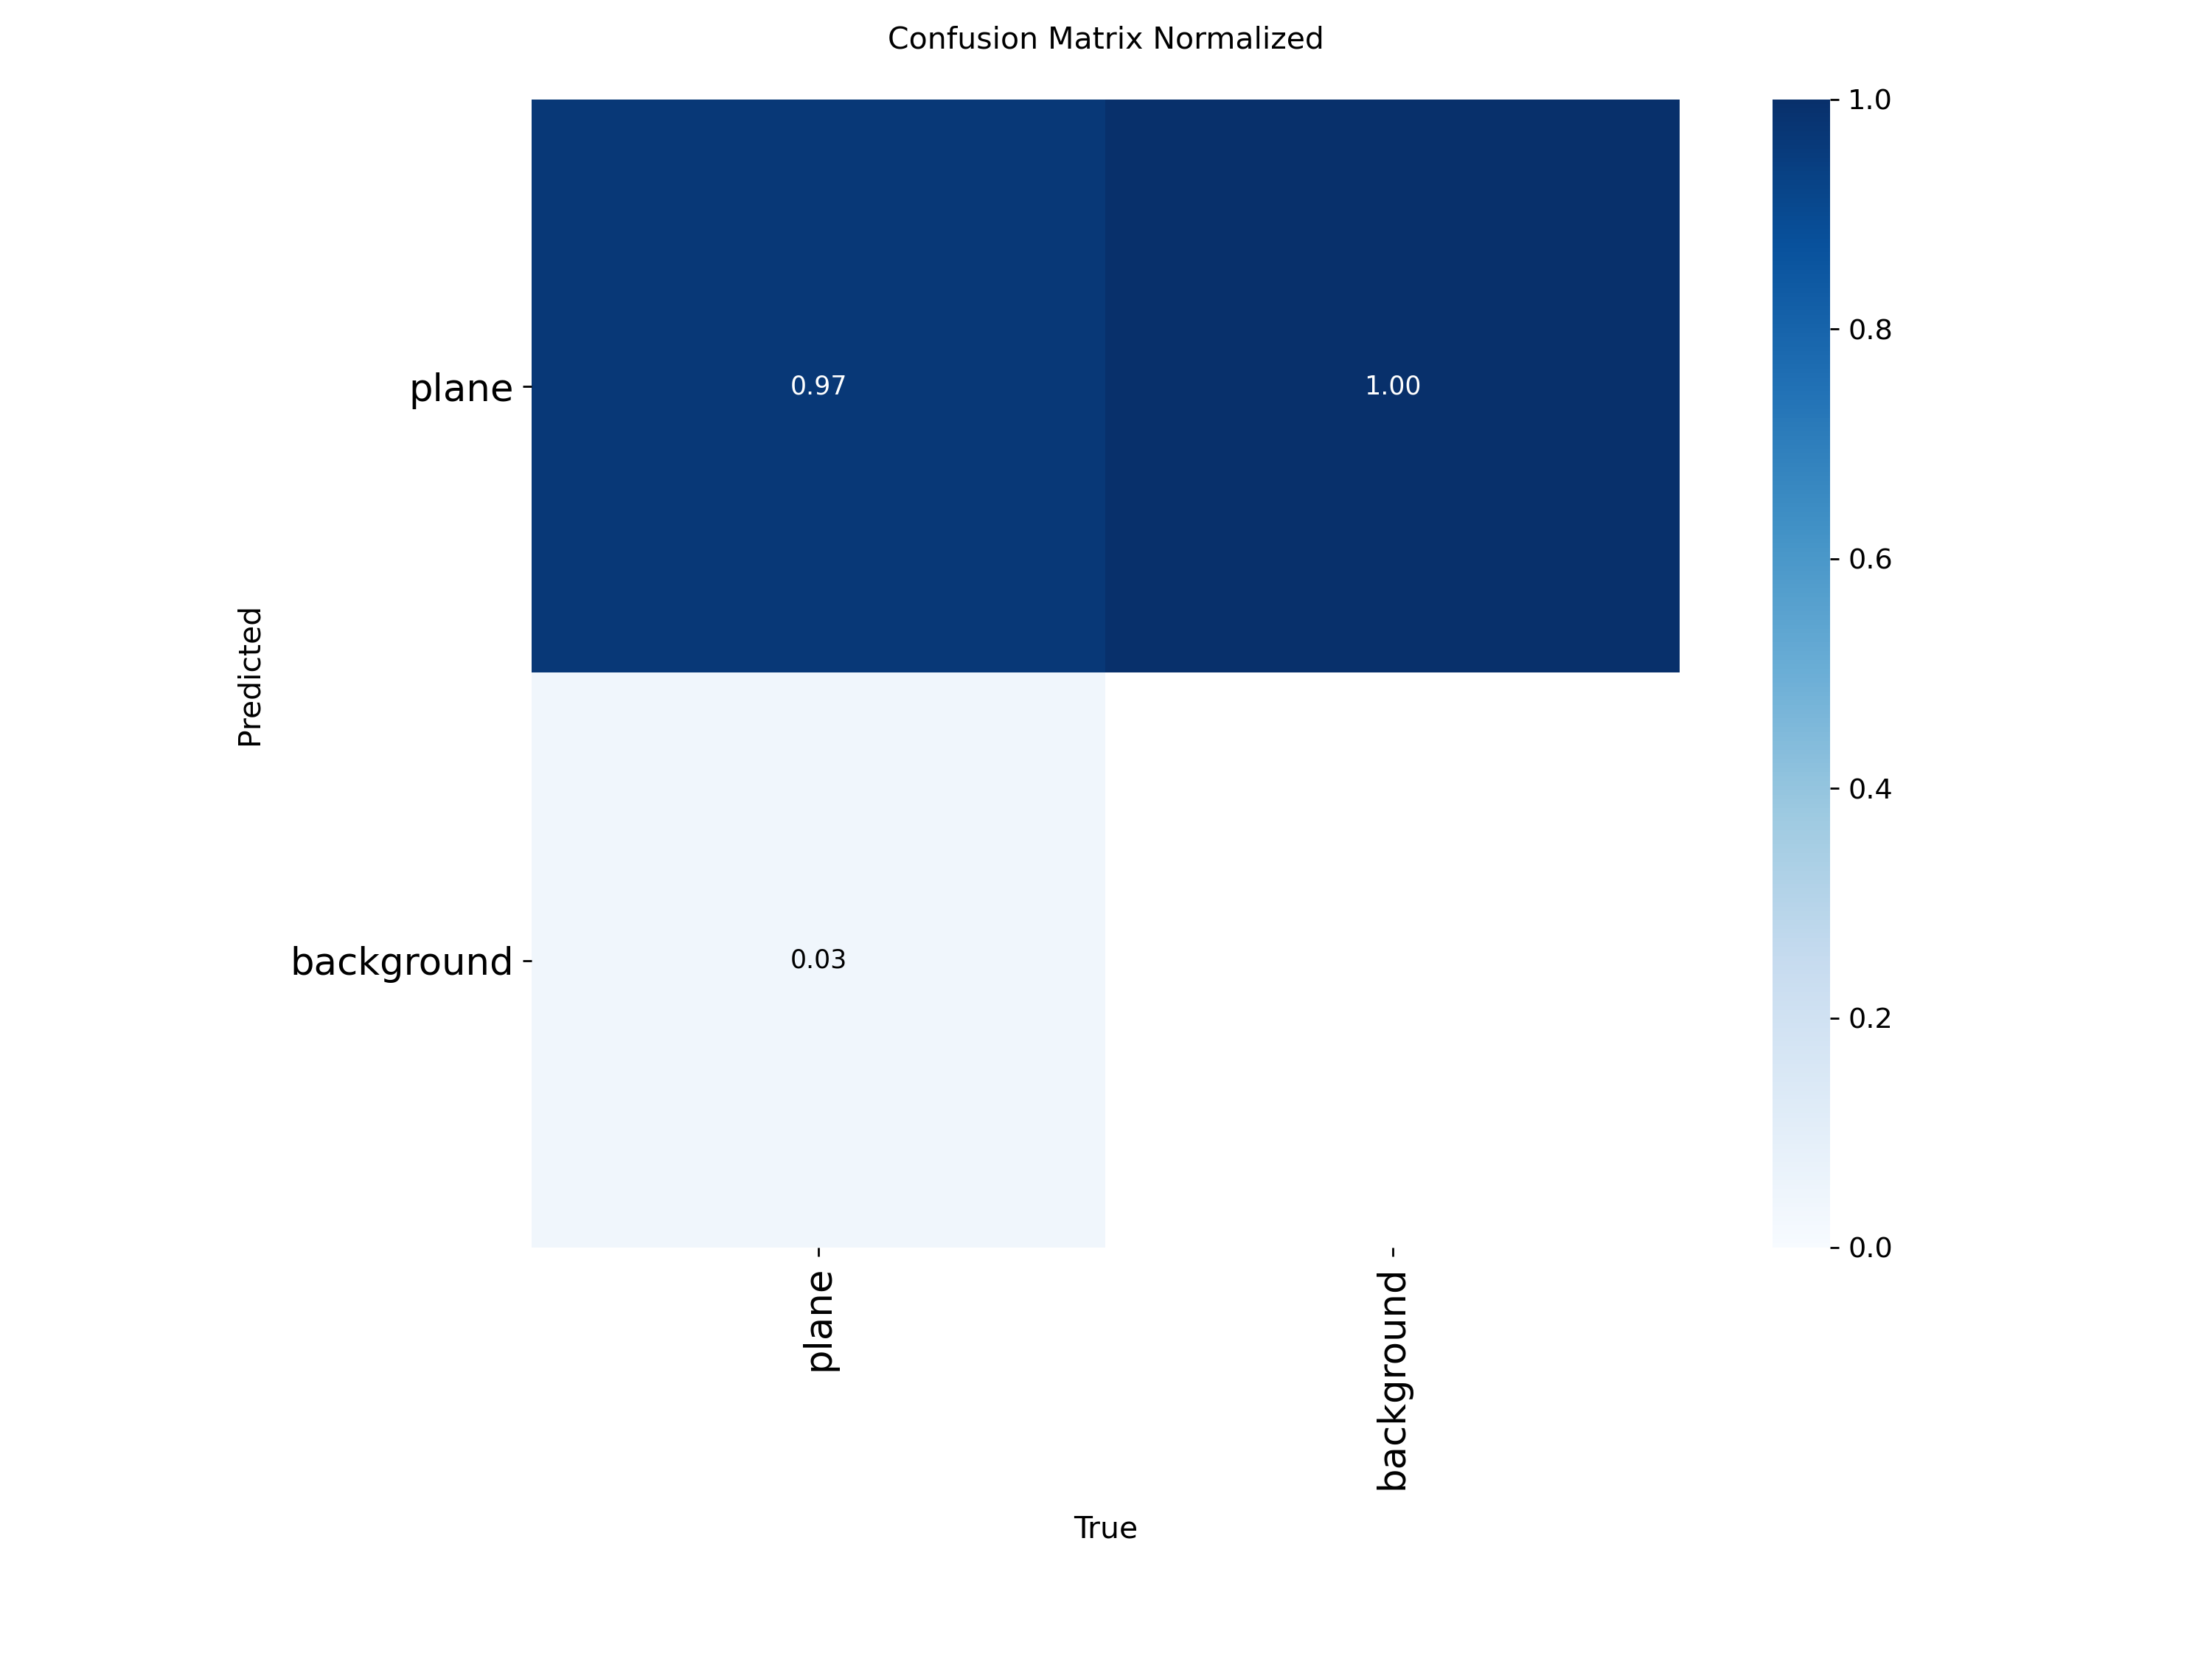

In [14]:
for path in sorted(glob.glob('runs/detect/val/*.png')):
    display(Image(filename=path))

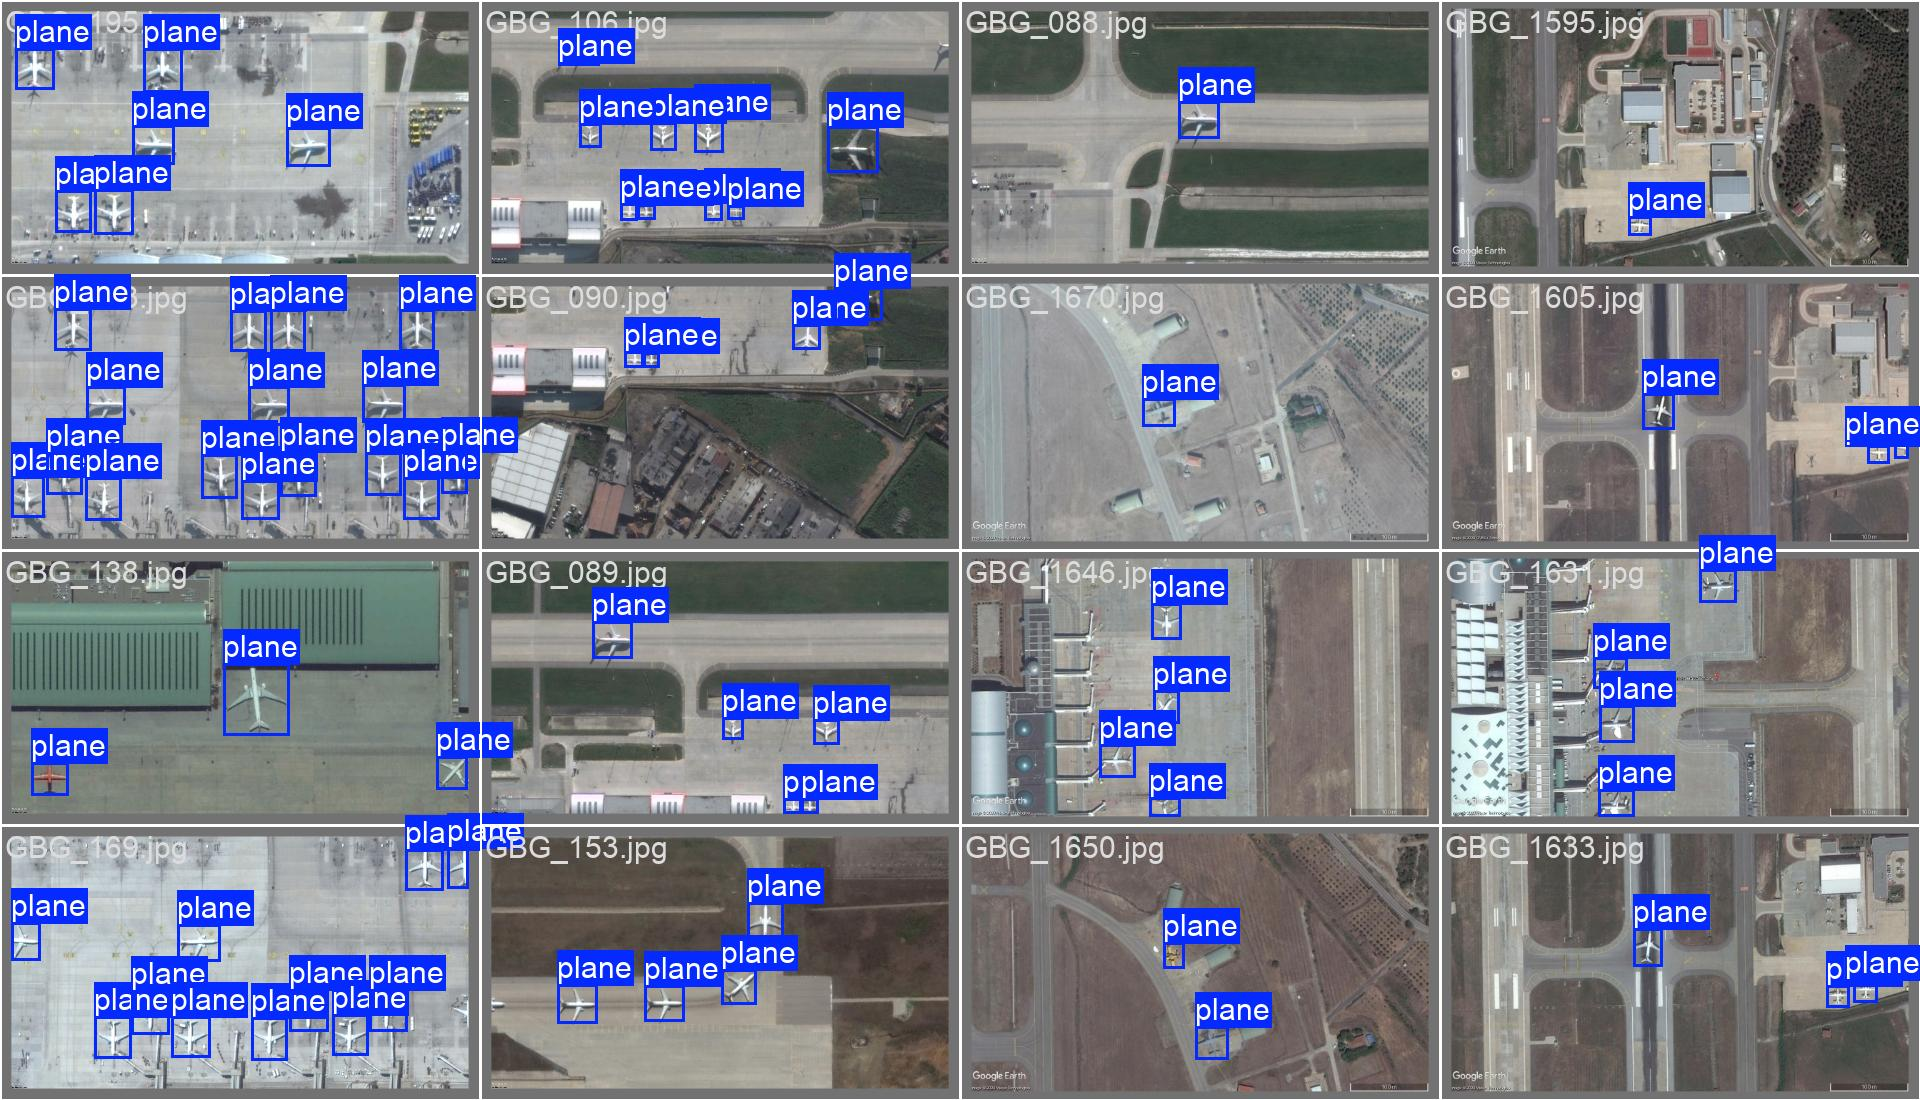

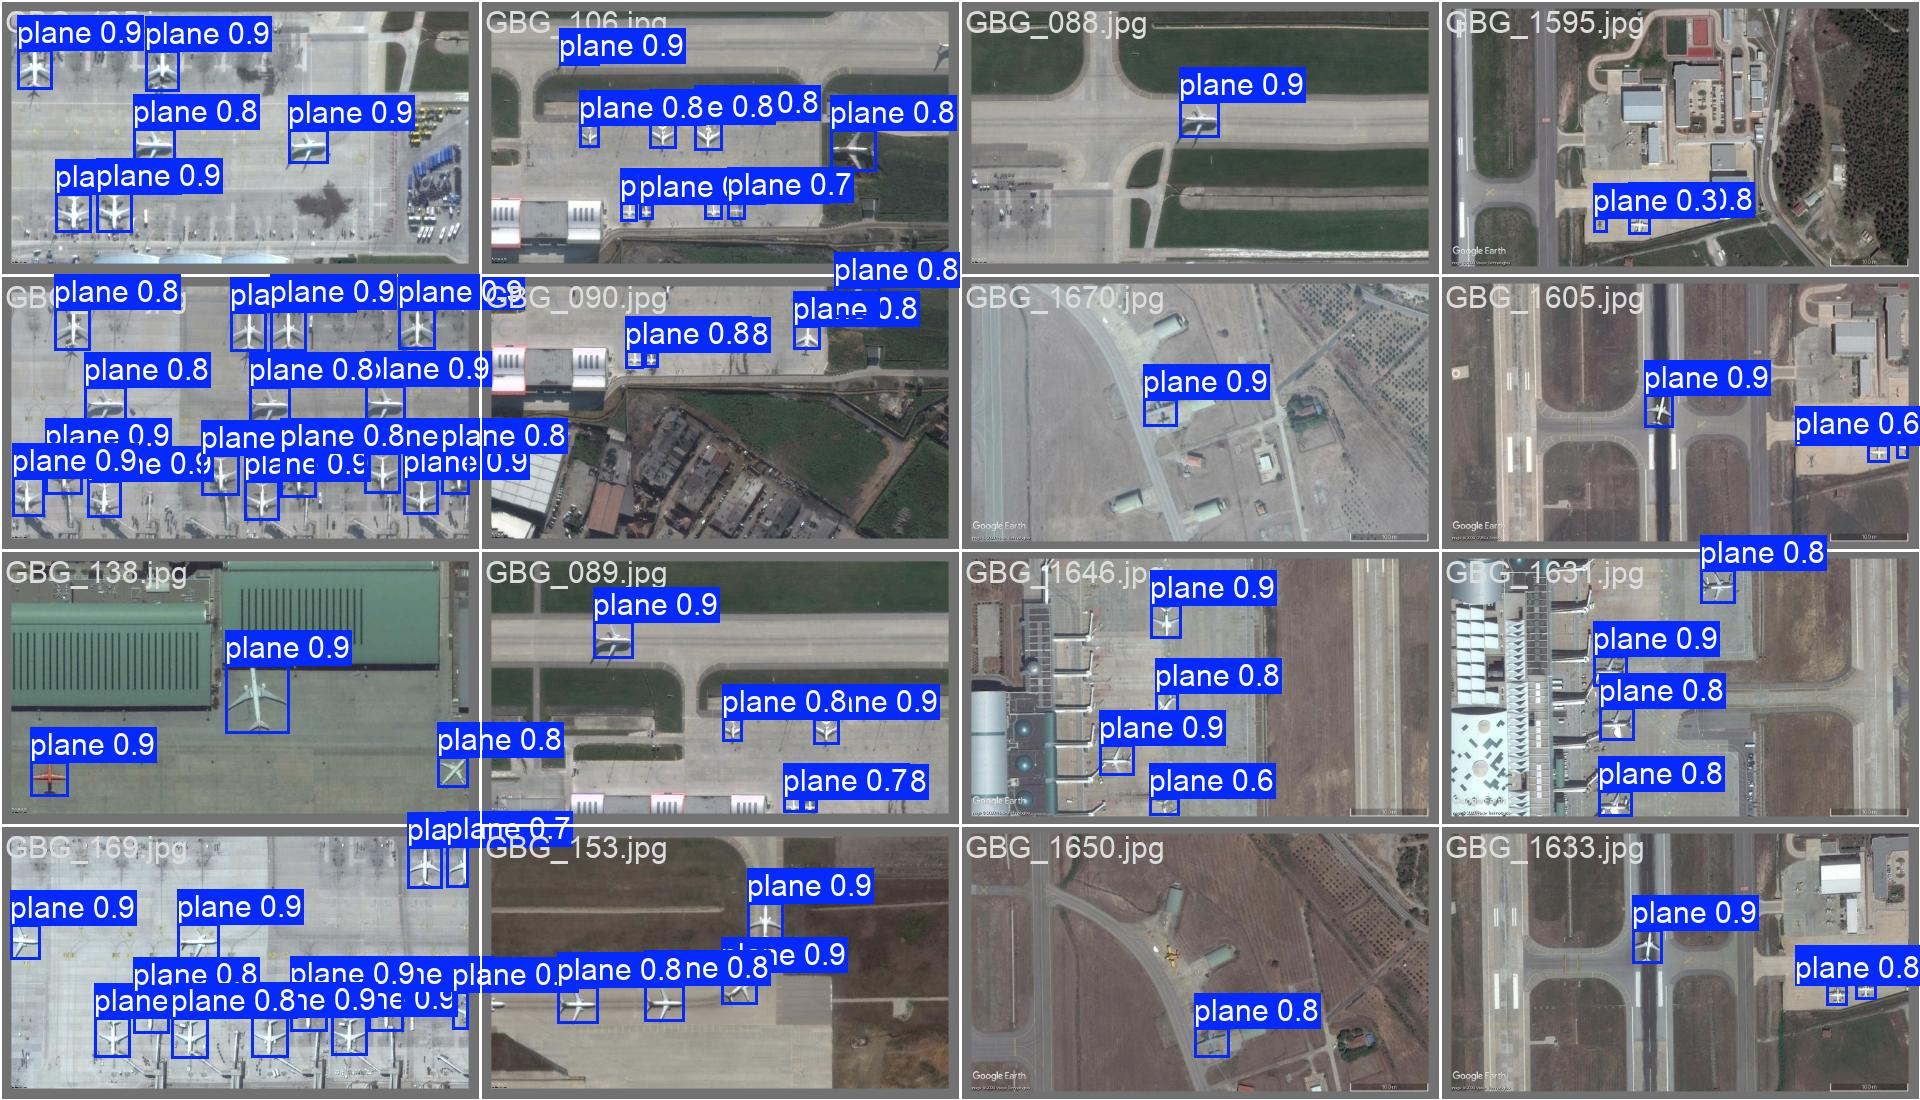

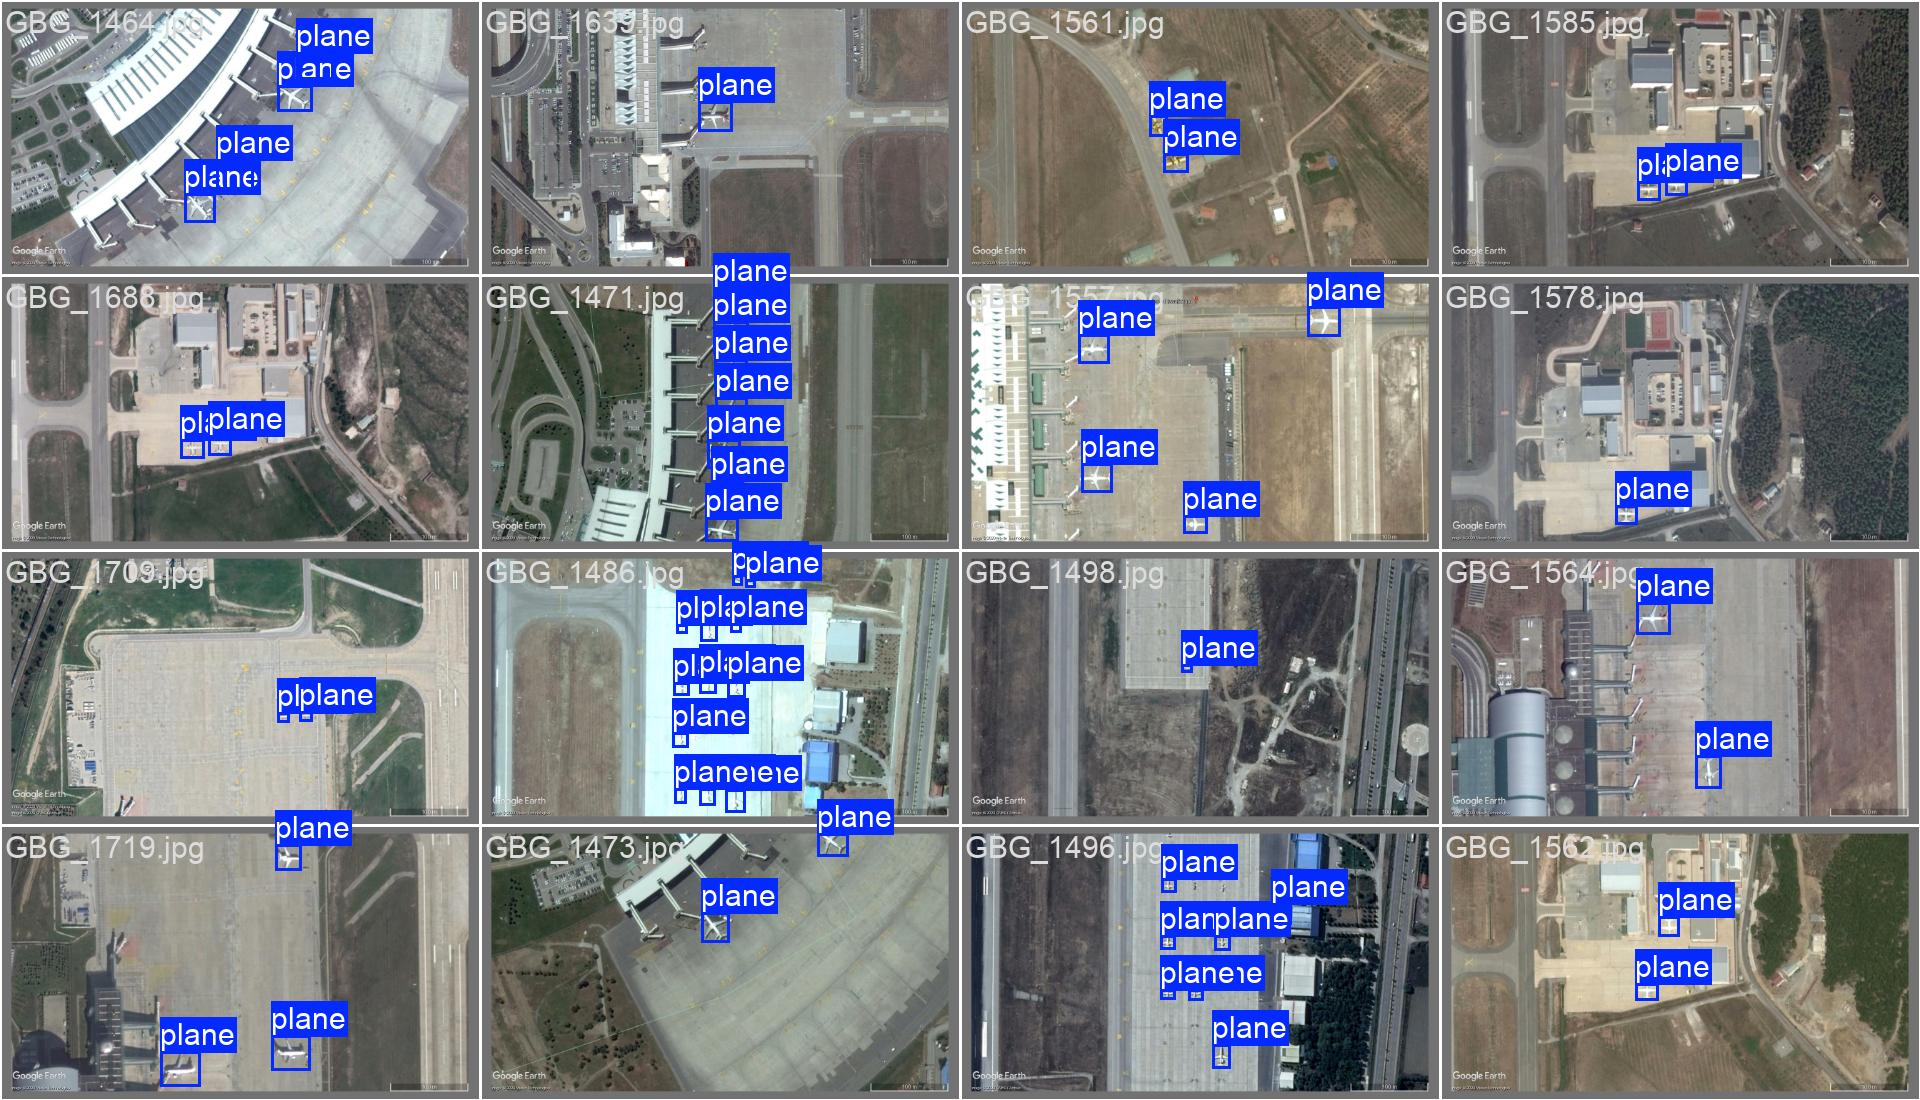

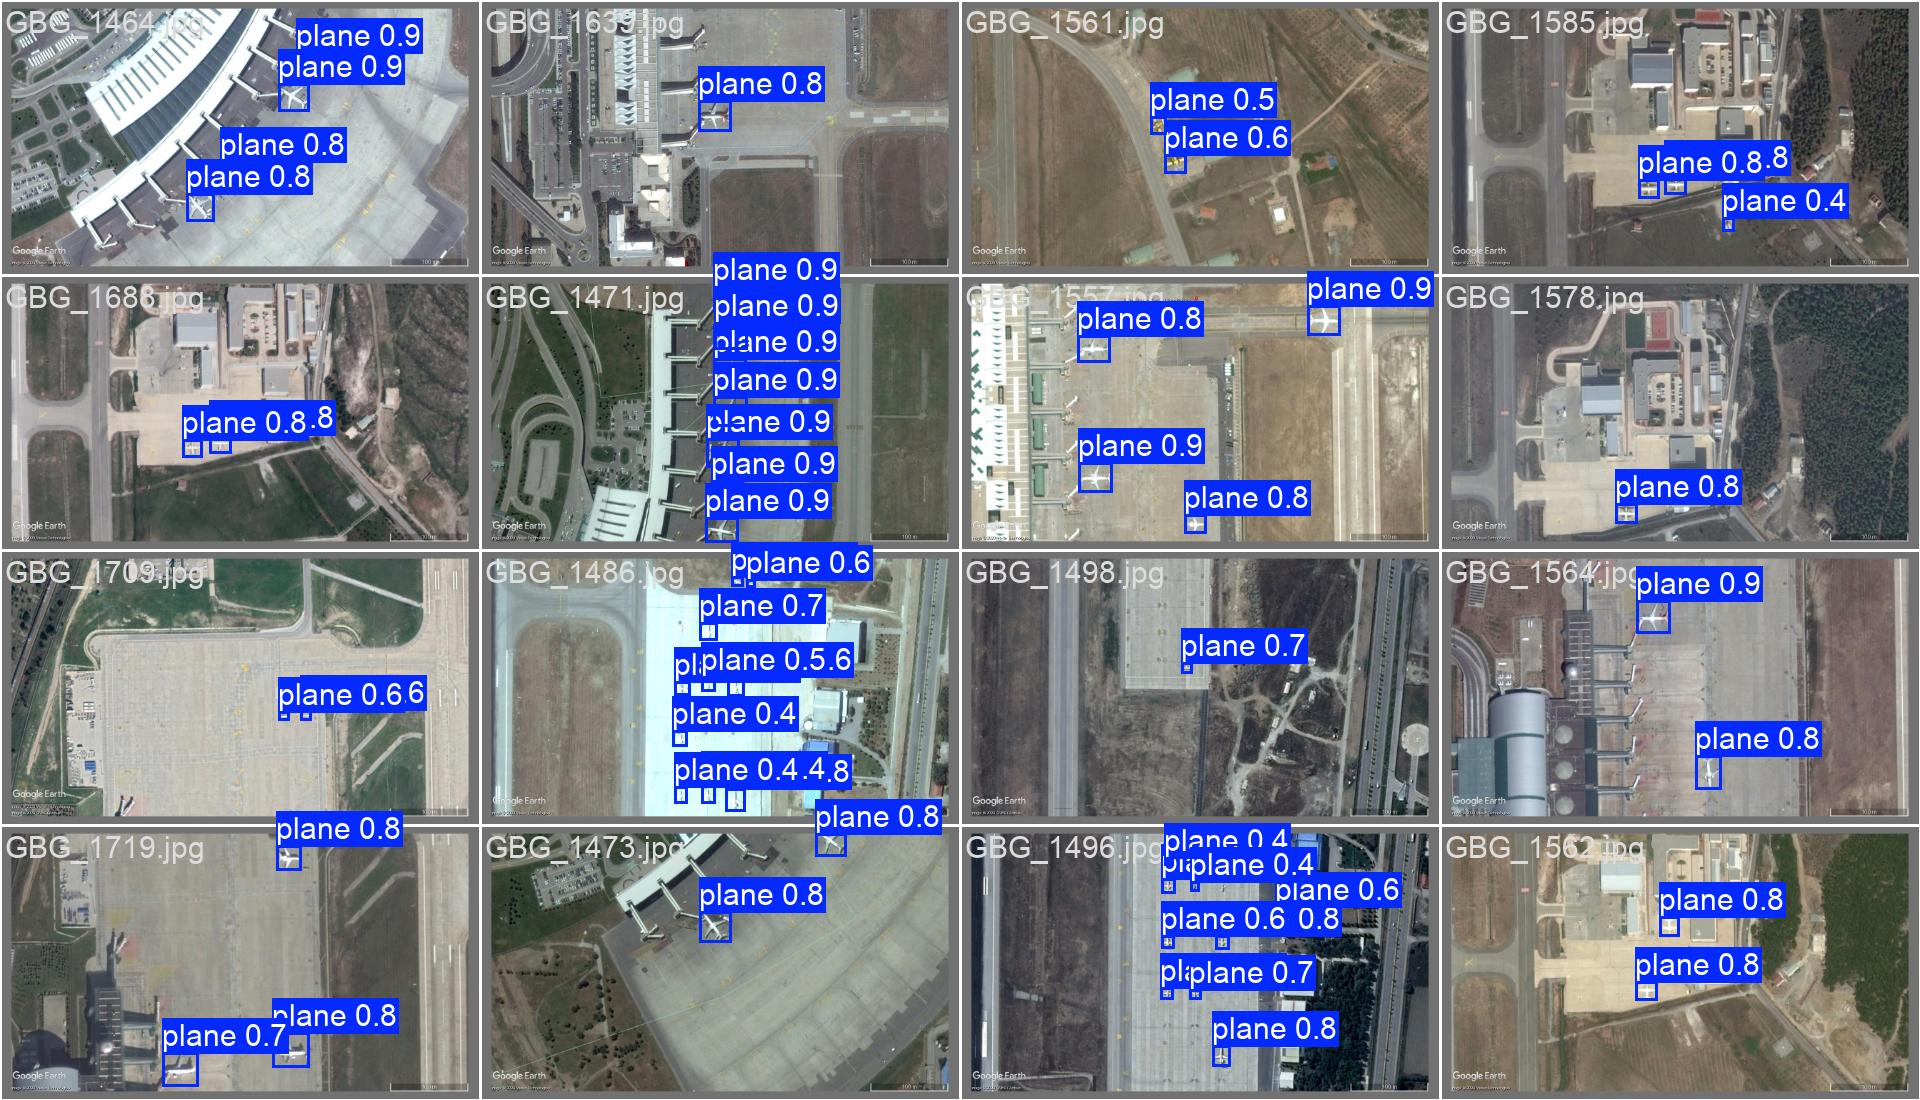

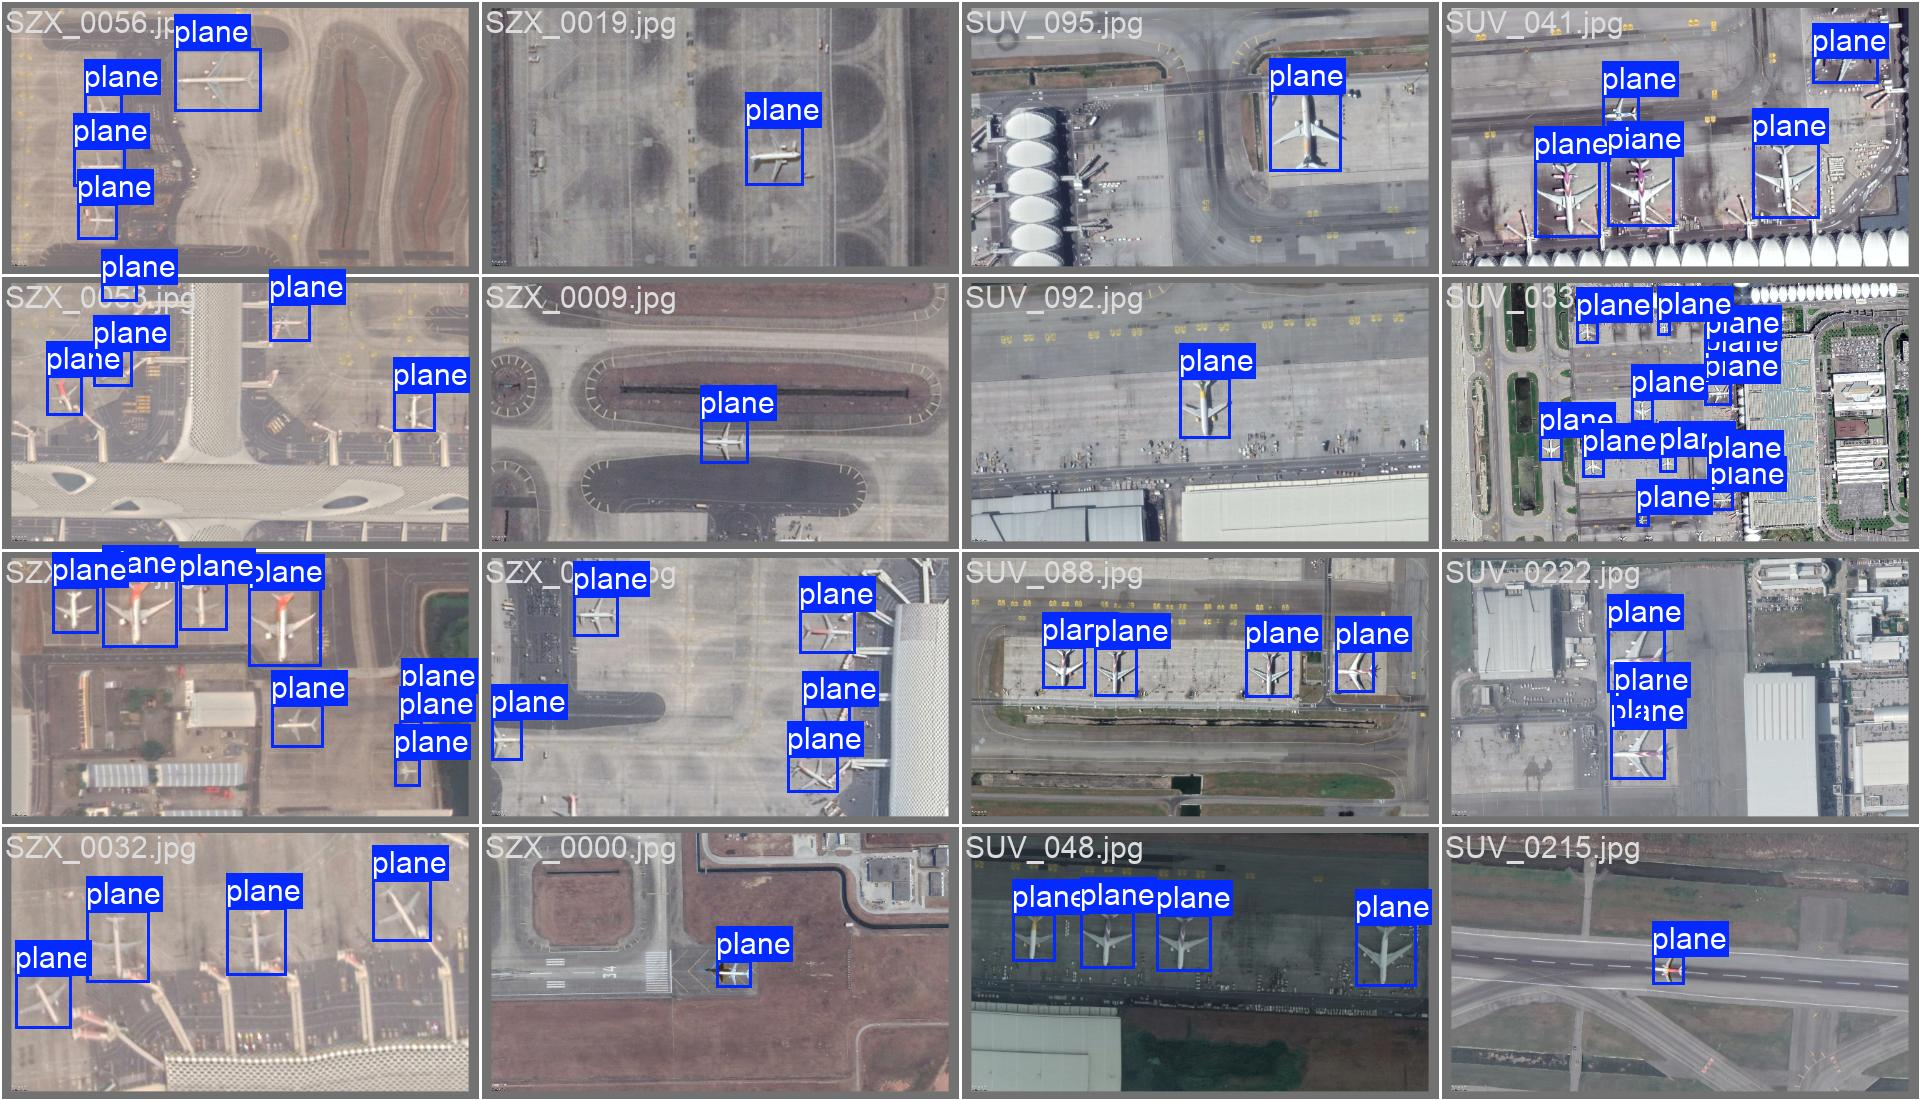

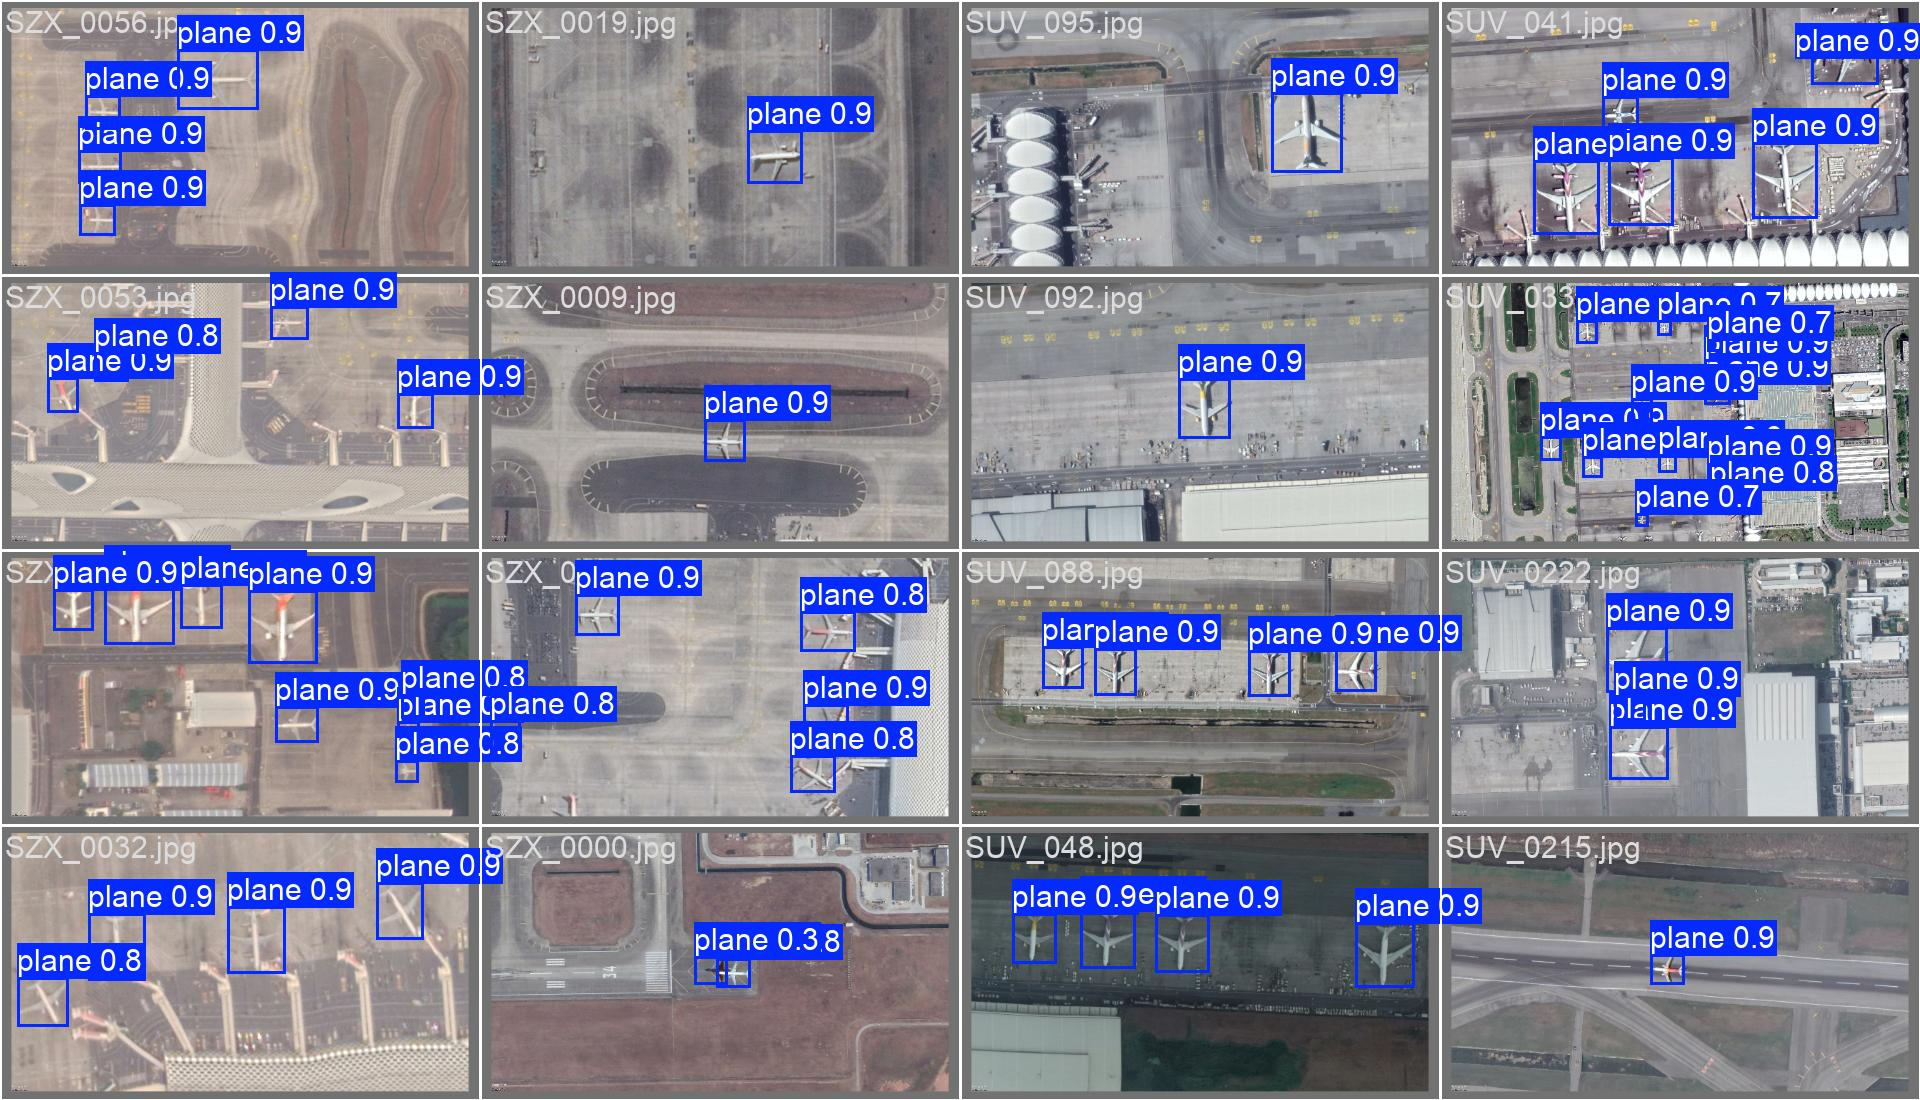

In [15]:
for path in sorted(glob.glob('runs/detect/val/*.jpg')):
    display(Image(filename=path))

In [ ]:
import shutil
from pathlib import Path

base_dir = Path('dataset')
img_dir = base_dir / 'img'
output_dir = base_dir / 'yolo_dataset'

for split in ['train', 'val']:
    (output_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
    (output_dir / 'labels' / split).mkdir(parents=True, exist_ok=True)

with open(base_dir / 'train.txt', 'r') as f:
    train_files = [line.strip().split('/')[-1].replace('.jpg', '') for line in f if line.strip()]

with open(base_dir / 'test.txt', 'r') as f:
    test_files = [line.strip().split('/')[-1].replace('.jpg', '') for line in f if line.strip()]

val_files = test_files

print(f"Train images: {len(train_files)}")
print(f"Val images: {len(val_files)}")

def copy_files(file_list, split):
    for filename in file_list:
        img_file = None
        for ext in ['.jpg']:
            if (img_dir / f'{filename}{ext}').exists():
                img_file = img_dir / f'{filename}{ext}'
                break
        
        if img_file and img_file.exists():
            shutil.copy(img_file, output_dir / 'images' / split / img_file.name)
            
            label_file = img_dir / f'{filename}.txt'
            if label_file.exists():
                shutil.copy(label_file, output_dir / 'labels' / split / f'{filename}.txt')
            else:
                (output_dir / 'labels' / split / f'{filename}.txt').touch()
                print(f"Warning: No label for {filename}")

copy_files(train_files, 'train')
copy_files(val_files, 'val')

print("Done!")

Train images: 2170
Val images: 311
Done!
